In [1]:
import random
import dotenv
import pathlib
import os
random.seed(2024)
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")  # directs to gpfs in scratch

In [1]:
from ctd.comparison.analysis.tt.tt import Analysis_TT

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250312_3BFF_NODE/max_epochs=1000_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=1.00E-01_latent_size=3_layer_hidden_size=64"
node_3bff = Analysis_TT(run_name = "node_3bff", filepath = path + "/")

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250319_3BFF_full_testFP/max_epochs=500_weight_decay=1.00E-08_learning_rate=5.00E-03_seed=0_noise=5.00E-02_latent_size=128"
full_3bff = Analysis_TT(run_name = "full_3bff", filepath = path + "/")

# node_3bff.plot_trial_io(num_trials = 2)
# node_3bff.plot_trial_latents(num_trials = 10)

full_3bff.plot_fps(
                    num_traj=10,
                    n_inits=1024,
                    noise_scale=0.0,
                    learning_rate=1e-3,
                    max_iters=10000,
                    device="cpu",
                    seed=0,
                    compute_jacobians=True,
                    q_thresh=1e-3,
                    n_pca_components=3,
                    return_pca_model = False,
                    do_pca=False,
                    plot_only_points=False,
                    return_points = False,
                )

AttributeError: 'tuple' object has no attribute 'squeeze'

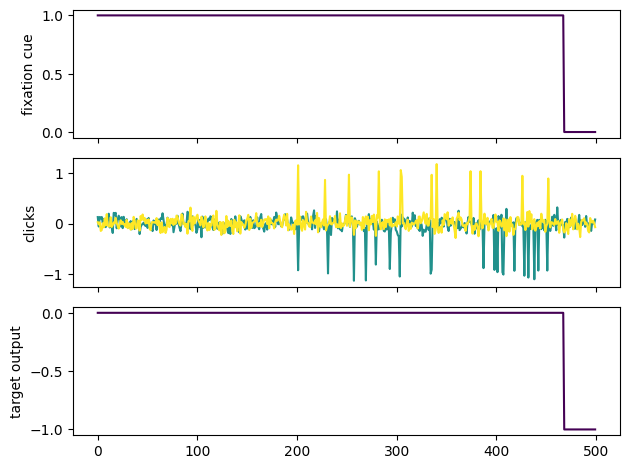

In [1]:
## Pclicks task - just like Luo et al 2023
from ctd.task_modeling.task_env.task_env import PClicks

pc = PClicks(n_timesteps= 500, noise= 0.1, rateL=30)  # Hz

pc.render()

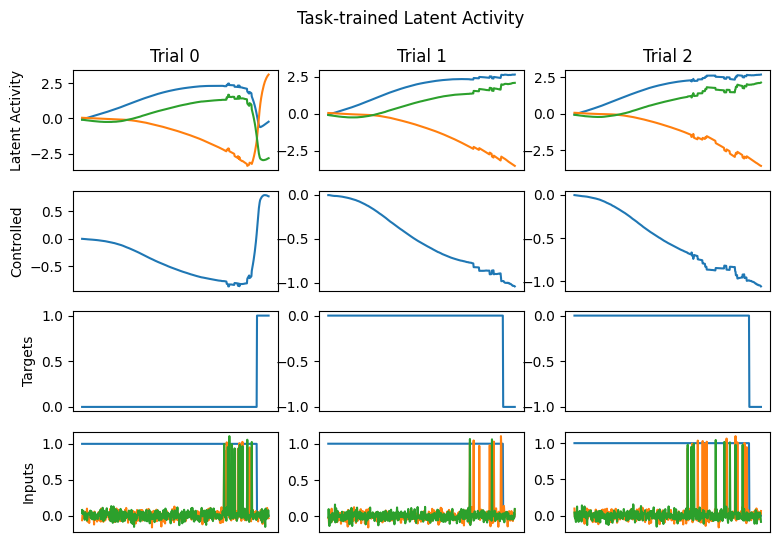

In [4]:
# first very short training on PClicks - loss was 0 always and something is prob wrong
from ctd.comparison.analysis.tt.tt import Analysis_TT

# 39:1 ratio should be very easy
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250316_PClicks_NODE"
tune39 = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune39_2lat = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune26 = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=5.00E-02_rateL=26_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-10"

node_pclicks_39 = Analysis_TT(run_name = "node_pclicks_39", filepath = path + "/" + tune39 + "/")
node_pclicks_26 = Analysis_TT(run_name = "node_pclicks_26", filepath = path + "/" + tune26 + "/")
node_pclicks_39_2lat = Analysis_TT(run_name = "node_pclicks_39_2lat", filepath = path + "/" + tune39_2lat + "/")

# node_pclicks_39.plot_trial_io(num_trials = 3)
node_pclicks_26.plot_trial_io(num_trials = 3)
# node_pclicks_39_2lat.plot_trial_io(num_trials = 3)

# NOTE that running pca takes maximum variance and plotting the trajectories might magnify any noise in them

# choose pca and/or tsne when >3 latents
# node_pclicks_26.plot_trial_latents(num_trials = 50, reduce_3_latents=False, pca=True)
# node_pclicks_39.plot_trial_latents(num_trials = 20, reduce_3_latents=False, pca=True)
# node_pclicks_39_2lat.plot_trial_latents(num_trials = 20, reduce_3_latents=False, pca=True)

# plot the trajs and fixed points
# node_pclicks_39_2lat.plot_fps(
#                     num_traj=10,
#                     n_inits=2048,
#                     noise_scale=0.0,
#                     learning_rate=1e-3,  # higher LR brings up spurious unstable points
#                     max_iters=10000,
#                     device="cpu",
#                     seed=0,
#                     compute_jacobians=True,
#                     q_thresh=1e-5,
#                     n_pca_components=3,
#                     return_pca_model = False,
#                     do_pca=False,
#                     plot_only_points=False,
#                     return_points = False,
#                 )

# the fixed points for the well trained model are clearly coherent with previous lit

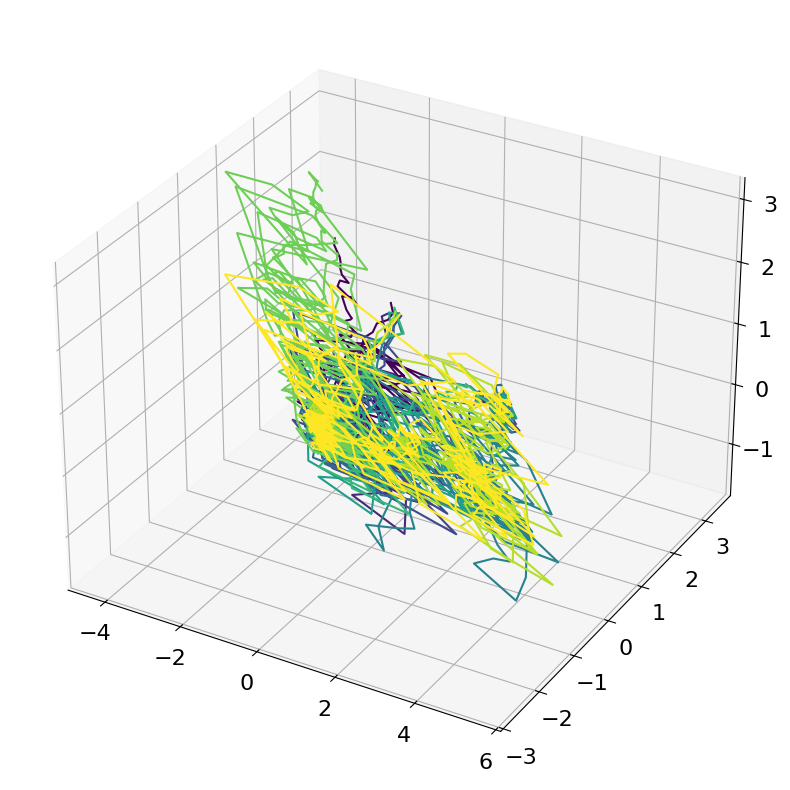

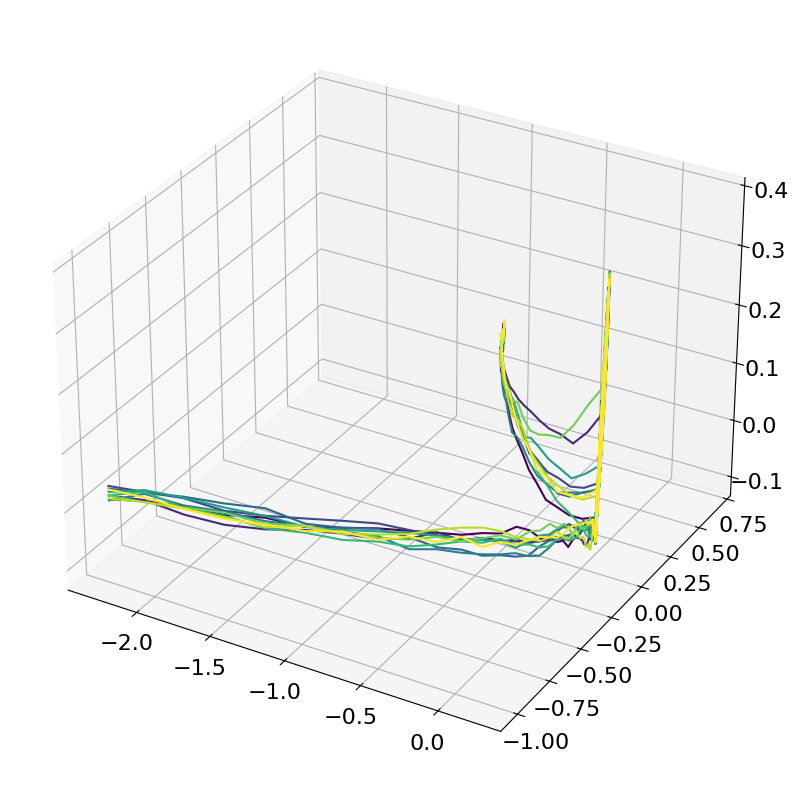

AttributeError: 'FullRankRNN' object has no attribute 'cell'

In [1]:
# FullRankRNN

from ctd.comparison.analysis.tt.tt import Analysis_TT

# 26 not good
tune26 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250318_PClicks_full_26/max_epochs=500_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=26_latent_size=64"
# 39 good - tbh could just guess one side always and still not lose much
tune39 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250318_PClicks_full_39/max_epochs=500_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=16"

full_pclicks_26 = Analysis_TT(run_name = "full_pclicks_26", filepath = tune26 + "/")
full_pclicks_39 = Analysis_TT(run_name = "full_pclicks_39", filepath = tune39 + "/")

# io is showing PCA latents
# full_pclicks_26.plot_trial_io(num_trials=10)
# full_pclicks_39.plot_trial_io(num_trials=10)

# also showing PCA
full_pclicks_26.plot_trial_latents(num_trials=10)
full_pclicks_39.plot_trial_latents(num_trials=10)

# plot the trajs and fixed points - NEED CELL
full_pclicks_39.plot_fps(
                    num_traj=10,
                    n_inits=2048,
                    noise_scale=0.0,
                    learning_rate=1e-3,  # higher LR brings up spurious unstable points
                    max_iters=10000,
                    device="cpu",
                    seed=0,
                    compute_jacobians=True,
                    q_thresh=1e-5,
                    n_pca_components=3,
                    return_pca_model = False,
                    do_pca=False,
                    plot_only_points=False,
                    return_points = False,
                )

In [ ]:
# visualize simulated neural dataset
import h5py

# LIKE THE LUO 2023 PAPER: simulate dataset with the same number of neurons, trials, and firing rate as the real data

# easy pclicks trials simulated from NODE
path = "/scratch/gpfs/ad2002/content/datasets/dt/20250316_PClicks_NODE/max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune = "heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5"
sim_data = path + "/" + tune

# this is from the data_training datamodule
with h5py.File(data_path, "r") as h5file:
    # Load the data
    train_data = to_tensor(h5file["train_encod_data"][()])
    valid_data = to_tensor(h5file["valid_encod_data"][()])
    train_recon_data = to_tensor(h5file["train_recon_data"][()])
    valid_recon_data = to_tensor(h5file["valid_recon_data"][()])
    # Load the activity
    train_activity = to_tensor(h5file["train_activity"][()])
    valid_activity = to_tensor(h5file["valid_activity"][()])
    # Load the latents
    train_latents = to_tensor(h5file["train_latents"][()])
    valid_latents = to_tensor(h5file["valid_latents"][()])
    # Load the indices
    train_inds = to_tensor(h5file["train_inds"][()])
    valid_inds = to_tensor(h5file["valid_inds"][()])
    # Load other parameters
    self.orig_mean = h5file["orig_mean"][()]
    self.orig_std = h5file["orig_std"][()]
    self.readout = h5file["readout"][()]
    train_inputs = h5file["train_inputs"][()]
    valid_inputs = h5file["valid_inputs"][()]
    train_extra = h5file["train_extra"][()]
    valid_extra = h5file["valid_extra"][()]

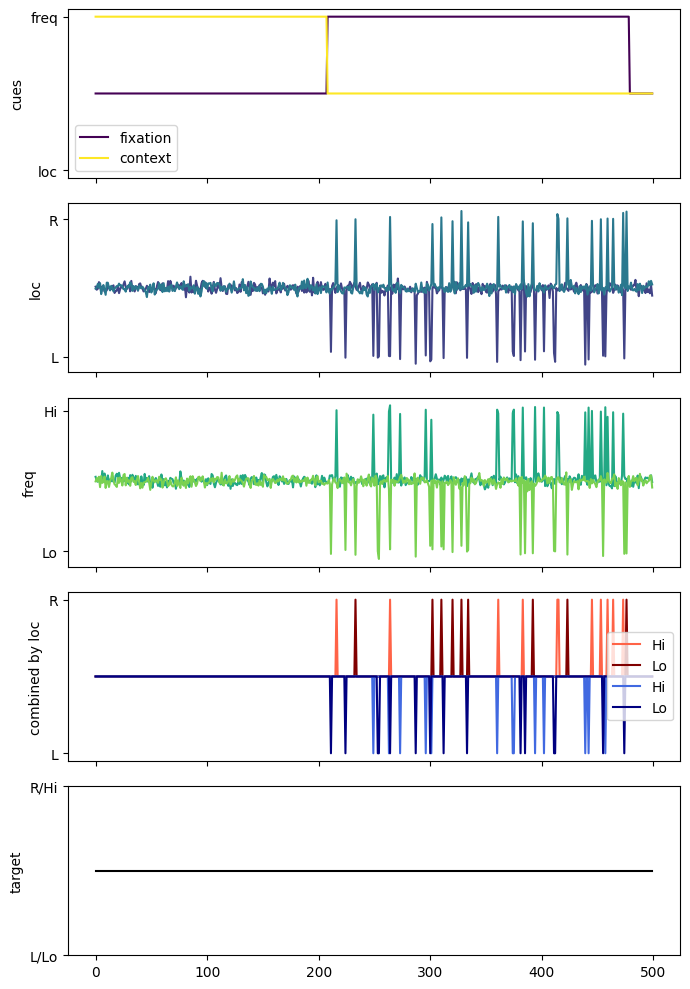

In [8]:
## Marino Pagan task - just like the paper
# note that there is a very small but non-zero chance that the target output should be 0 (if everything has tied)

from ctd.task_modeling.task_env.task_env import MarinoPagan

mp = MarinoPagan(n_timesteps= 500, noise= 0.05, rateL=20)  # Hz

mp.render()

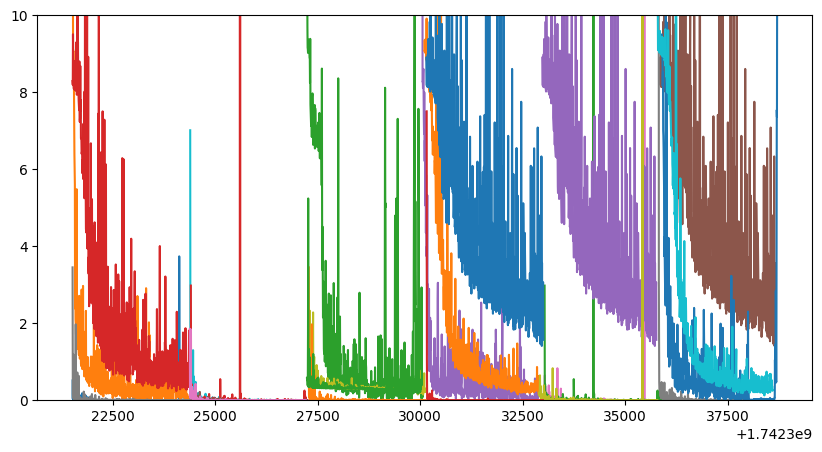

In [13]:
# compare the training dynamics of all tunes for one model on one task
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_progress_files(directory):
    progress_files = []
    labels = []
    
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        progress_file = os.path.join(folder_path, 'progress.csv')
        
        if os.path.isdir(folder_path) and os.path.isfile(progress_file) and os.path.getsize(progress_file) > 0:
            progress_files.append(progress_file)
            labels.append(folder_path)
    
    return progress_files, labels

# partial NODE in TEST
# dir = "/scratch/gpfs/ad2002/content/runs/task-trained/20250316_PClicks_NODE/train_2025-03-16_21-29-27/"

# full NODE in SHARE - the second blue explodes in gradient: rate 1, latent 10 - got 24 out of the total 48, but prob can get one of each 
# type save the learning rate...
dir = "/scratch/gpfs/ad2002/content/runs/task-trained/20250318_PClicks_NODE_full/train_2025-03-18_14-11-40"

fig, ax = plt.subplots(figsize=(10, 5))
progress_files, labels = find_progress_files(dir)
for i in range(len(progress_files)):  
    file = progress_files[i]
    df = pd.read_csv(file)
    ax.plot(df['timestamp'], df['loss'], label=labels[i])
    #ax.legend()

ax.set_ylim([0, 10])

plt.show()

# plotting both easy and hard trials: for easy size 2 lr 1e-2 is the best (3-10 not necesarily better, but higher lr means more spikey),
# for 26 size 10 is best

# could increase the lat weight to make the latents more stable